In [1]:
from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd
from sklearn import datasets
from sklearn import linear_model

from sklearn.model_selection import train_test_split

from sklearn.metrics import r2_score, mean_squared_error

In [2]:
# setup: has to be in a separate cell for some reason
plt.rcParams['figure.figsize'] = [10, 5]

Import X and y from data prep steps

In [3]:
X = np.load('X.npy')
y = np.load('y.npy')

In [4]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

# Linear regression  
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.MultiTaskLasso.html

0.5747556485365626
4.649979126731396


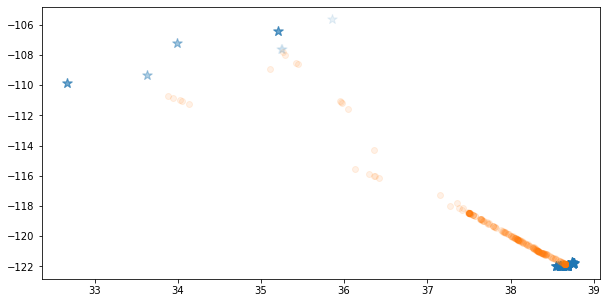

In [5]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1298)

MTLReg = linear_model.MultiTaskLasso(alpha=0.1)
MTLReg.fit(X_train, y_train)
#print(MTLReg.coef_)
#print(MTLReg.intercept_)
preds = MTLReg.predict(X_test)

#plt.scatter(y_test, preds) #should this be [:,1] for both? ASK ANDY
#plt.scatter(y_test[:,1], preds[:,1])

#use scikit-learn scorer
print(r2_score(y_test,preds))
print(mean_squared_error(y_test,preds))

LR_rsq = r2_score(y_test,preds)
LR_mse = mean_squared_error(y_test,preds)

y_test = np.hsplit(y_test, 2)

preds = np.hsplit(preds, 2)

plt.scatter(y_test[0], y_test[1], marker='*', alpha=0.1, s=100)
plt.scatter(preds[0], preds[1], alpha=0.1)

# SVR Support Vector Regression multioutput regressor
https://medium.com/pursuitnotes/support-vector-regression-in-6-steps-with-python-c4569acd062d  
https://scikit-learn.org/stable/modules/svm.html#regression
https://datascience.stackexchange.com/questions/82743/valueerror-y-should-be-a-1d-array-got-an-array-of-shape-285-30-instead  
https://www.section.io/engineering-education/support-vector-regression-in-python/

0.8054131650313805
0.15338321885632988


(-1.0, 1.0)

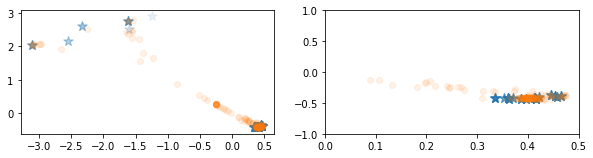

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

X = np.load('X.npy')
y = np.load('y.npy')
from sklearn.preprocessing import StandardScaler #scaling gets a slightly lower r2 but much less error
sc_X = StandardScaler() 
sc_y = StandardScaler()
X = sc_X.fit_transform(X)
y = sc_y.fit_transform(y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1298)

# Create the SVR regressor
svr = SVR(epsilon=0.01)

# Create the Multioutput Regressor
mor = MultiOutputRegressor(svr)

# Train the regressor
mor = mor.fit(X_train, y_train)

# Generate predictions for testing data
preds = mor.predict(X_test)

#plt.scatter(y_test, preds) #should this be [:,1] for both?
#plt.scatter(y_test[:,1], preds[:,1])

#use scikit-learn scorer
print(r2_score(y_test,preds))
print(mean_squared_error(y_test,preds))
SVR_rsq = r2_score(y_test,preds)
SVR_mse = mean_squared_error(y_test,preds)

y_test = np.hsplit(y_test, 2)
preds = np.hsplit(preds, 2)

plt.subplot(2,2,1)
plt.scatter(y_test[0], y_test[1], marker='*', alpha=0.1, s=100)
plt.scatter(preds[0], preds[1], alpha=0.1)
plt.subplot(2,2,2)
plt.scatter(y_test[0], y_test[1], marker='*', alpha=0.1, s=100)
plt.scatter(preds[0], preds[1], alpha=0.1)
plt.xlim(0.0,0.5)
plt.ylim(-1,1)

# k-Nearest Neighbors for Multioutput Regression
https://machinelearningmastery.com/multi-output-regression-models-with-python/

0.8978479164481685
0.08021236041147481


(-1.0, 0.0)

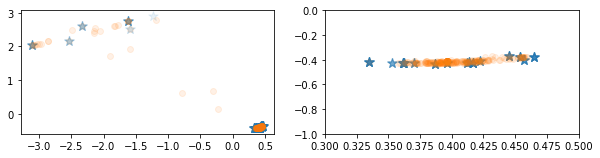

In [7]:
from sklearn.datasets import make_regression
from sklearn.neighbors import KNeighborsRegressor

X = np.load('X.npy')
y = np.load('y.npy')
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()
X = sc_X.fit_transform(X)
y = sc_y.fit_transform(y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1298)

# fit model
KNR = KNeighborsRegressor(algorithm='auto', weights='distance') #slightly better when weighted by distance
KNR = KNR.fit(X_train, y_train)

preds = KNR.predict(X_test)
#plt.scatter(y_test, preds) #should this be [:,1] for both?
#plt.scatter(y_test[:,1], preds[:,1])

#use scikit-learn scorer
print(r2_score(y_test,preds))
print(mean_squared_error(y_test,preds))

KNR_rsq = r2_score(y_test,preds)
KNR_mse = mean_squared_error(y_test,preds)

y_test = np.hsplit(y_test, 2)
preds = np.hsplit(preds, 2)

plt.subplot(2,2,1)
plt.scatter(y_test[0], y_test[1], marker='*', alpha=0.1, s=100)
plt.scatter(preds[0], preds[1], alpha=0.1)
plt.subplot(2,2,2)
plt.scatter(y_test[0], y_test[1], marker='*', alpha=0.1, s=100)
plt.scatter(preds[0], preds[1], alpha=0.1)
plt.xlim(0.3,0.5)
plt.ylim(-1,0)

# Decision Tree for multioutput regression  


0.9055384317134219
0.07350930820514548


(-1.0, 0.0)

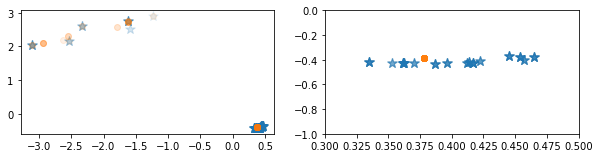

In [8]:
# decision tree for multioutput regression
from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor
X = np.load('X.npy')
y = np.load('y.npy')
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()
X = sc_X.fit_transform(X)
y = sc_y.fit_transform(y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1298)

# fit model
DTR = DecisionTreeRegressor(max_depth=5)
DTR = DTR.fit(X_train, y_train)

preds = DTR.predict(X_test)
#plt.scatter(y_test, preds) #should this be [:,1] for both?
#plt.scatter(y_test[:,1], preds[:,1])

#use scikit-learn scorer
print(r2_score(y_test,preds))
print(mean_squared_error(y_test,preds))

DTR_rsq = r2_score(y_test,preds)
DTR_mse = mean_squared_error(y_test,preds)

y_test = np.hsplit(y_test, 2)
preds = np.hsplit(preds, 2)

plt.subplot(2,2,1)
plt.scatter(y_test[0], y_test[1], marker='*', alpha=0.1, s=100)
plt.scatter(preds[0], preds[1], alpha=0.1)
plt.subplot(2,2,2)
plt.scatter(y_test[0], y_test[1], marker='*', alpha=0.1, s=100)
plt.scatter(preds[0], preds[1], alpha=0.1)
plt.xlim(0.3,0.5)
plt.ylim(-1,0)

In [9]:
method = ['Linear Regression', 'SVR Support Vector Regression' , 'k-Nearest Neighbors', 'Decision Tree']
rsquared = [LR_rsq, SVR_rsq, KNR_rsq, DTR_rsq]
MSE = [LR_mse, SVR_mse, KNR_mse, DTR_mse]

df = pd.DataFrame({'Method' : method,
              'rsquared' : rsquared,
              'MSE' : MSE})
df

,Method,rsquared,MSE
0,Linear Regression,0.574756,4.649979
1,SVR Support Vector Regression,0.805413,0.153383
2,k-Nearest Neighbors,0.897848,0.080212
3,Decision Tree,0.905538,0.073509


In [142]:
from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor
X = np.load('X.npy')
y = np.load('y.npy')
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()
X = sc_X.fit_transform(X)
y = sc_y.fit_transform(y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1298)

# fit model
DTR = DecisionTreeRegressor(max_depth=5)
DTR = DTR.fit(X_train, y_train)

preds = DTR.predict(X_test)

train_error = np.round(DTR.score(X_train, y_train), 2)
test_error = np.round(DTR.score(X_test, y_test), 2)
    
print("Training Set Mean Accuracy = " + str(train_error))
print("Test Set Mean Accuracy = " + str(test_error))

#scales outputs back to be lat and longs
y_new_inverse = sc_y.inverse_transform(y_test)
preds_new_inverse = sc_y.inverse_transform(preds)

y_inverse = np.hsplit(y_new_inverse, 2)
preds_inverse = np.hsplit(preds_new_inverse, 2)

Training Set Mean Accuracy = 0.93
Test Set Mean Accuracy = 0.91


Training Set Mean Accuracy = 1.0
Test Set Mean Accuracy = 0.98
R2 =  0.9803496265956515
mse =  0.19234618051521546


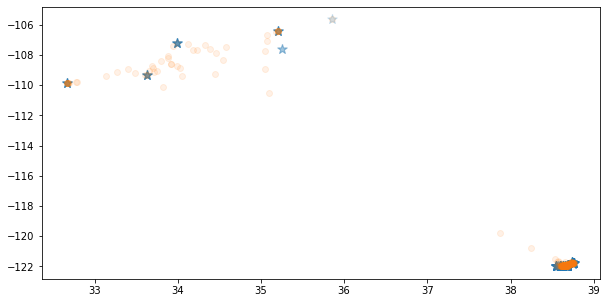

In [141]:
#random forest
# Splitting the dataset into the Training set and Test set

X = np.load('X.npy')
y = np.load('y.npy')
#from sklearn.cross_validation import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 1)
    
# Scaling
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test  = sc_X.transform(X_test)

# Random forest
from sklearn.ensemble import RandomForestRegressor
#rf =RandomForestRegressor(max_depth=2, n_estimators = 100, random_state=0) ###original
rf =RandomForestRegressor(n_estimators = 400, min_samples_split = 2, min_samples_leaf = 1, max_features = 'sqrt', max_depth = None, bootstrap = False) ###tuned
rf = rf.fit(X_train,y_train)
pred_train = rf.predict(X_train)
pred_test = rf.predict(X_test)

train_error = np.round(rf.score(X_train, y_train), 2)
test_error = np.round(rf.score(X_test, y_test), 2)    
print("Training Set Mean Accuracy = " + str(train_error))
print("Test Set Mean Accuracy = " + str(test_error))

print("R2 = " + " " + str(r2_score(y_test,pred_test)))
print("mse = " + " " + str(mean_squared_error(y_test,pred_test)))

y_test = np.hsplit(y_test, 2)
pred_test = np.hsplit(pred_test, 2)


plt.scatter(y_test[0], y_test[1], marker='*', alpha=0.1, s=100)
plt.scatter(pred_test[0], pred_test[1], alpha=0.1)


https://towardsdatascience.com/hyperparameter-tuning-the-random-forest-in-python-using-scikit-learn-28d2aa77dd74

In [138]:
from sklearn.model_selection import RandomizedSearchCV
# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]
# Number of features to consider at every split
max_features = ['auto', 'sqrt']
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
max_depth.append(None)
# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10]
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4]
# Method of selecting samples for training each tree
bootstrap = [True, False]
# Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}
print(random_grid)

{'n_estimators': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000], 'max_features': ['auto', 'sqrt'], 'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'bootstrap': [True, False]}


In [139]:
rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, n_iter = 100, cv = 3, verbose=2, random_state=42, n_jobs = -1)
# Fit the random search model
rf_random.fit(X_train, y_train)

Fitting 3 folds for each of 100 candidates, totalling 300 fits


RandomizedSearchCV(cv=3,
                   estimator=RandomForestRegressor(max_depth=2, random_state=0),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, 110,
                                                      None],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000, 1200, 1400, 1600,
                                                         1800, 2000]},
                   random_state=42, verbose=2)

In [140]:
rf_random.best_params_

{'n_estimators': 400,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': None,
 'bootstrap': False}

lets see the top 10 features, looks like the most important is the unknown Asteraceae sPA (cultivated sunflower?) followed by Tanacetum corymbosum, a small white daisy
https://www.nbshare.io/notebook/312837011/Decision-Tree-Regression-With-Hyper-Parameter-Tuning-In-Python/

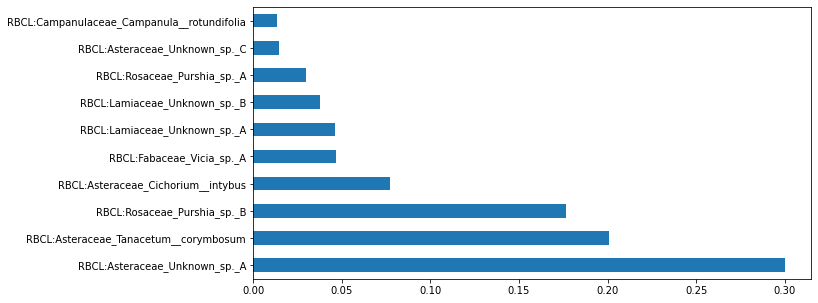

In [11]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score as acc
names = np.load('X_cols.npy', allow_pickle = True)
reg= ExtraTreesRegressor()
reg.fit(X_train,y_train)
importance = reg.feature_importances_
#print(np.column_stack((names, importance)))
feat_importances = pd.Series(reg.feature_importances_, index=names)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

In [12]:
#lets look at RBCL:Asteraceae_unknown_sp._A


In [112]:
import folium
from math import atan 
from folium.plugins import MarkerCluster

from geopy.distance import geodesic

 

#need to change outputs from two arrays with n rows to n arrays with 2 columns
y_test_new = np.column_stack((y_inverse[0],y_inverse[1])) 
preds_new = np.column_stack((preds_inverse[0],preds_inverse[1])) 
y_and_preds = np.concatenate((y_test_new,preds_new),axis=1)

def get_dists(real_predicted_coords):
    dists_list = []
    for line in real_predicted_coords:
        x = geodesic([line[0],line[1]], [line[2],line[3]]).mi
        dists_list.append(x)
    return dists_list
    
dists = get_dists(y_and_preds)

mapit = folium.Map( location=[36.1699, -115.1398], zoom_start=6)
folium.TileLayer('Stamen Terrain').add_to(mapit)
    
for coord in preds_new:
    folium.Marker( location=[ coord[0], coord[1] ], icon=folium.Icon(color="gray",icon="question-circle-o", prefix='fa'), radius=8 ).add_to( mapit )
    marker_cluster1 = MarkerCluster().add_to(mapit)
for coord in preds_new:
    folium.Marker(location=[ coord[0], coord[1] ], icon=folium.Icon(color="gray",icon="question-circle-o", prefix='fa')).add_to(marker_cluster1)

for coord in y_test_new:
    folium.Marker( location=[ coord[0], coord[1] ], icon=folium.Icon(color="green",icon="leaf", prefix='fa'), radius=8 ).add_to( mapit )    
marker_cluster = MarkerCluster().add_to(mapit)
for coord in y_test_new:
    folium.Marker(location=[ coord[0], coord[1] ], icon=folium.Icon(color="green",icon="leaf", prefix='fa'), radius=8).add_to(marker_cluster)

def assign_colors(dist_list):
    color_pick = []
    for lens in dists:
        if lens <= 5:
            color_pick.append('Green')
        elif 5 < lens <= 15:
            color_pick.append('Orange')
        elif lens > 15:
            color_pick.append('Red')
    return color_pick

my_colors = assign_colors(dists)    

marker_len = 0
for coord in y_and_preds:
    folium.PolyLine(locations = ([ coord[0], coord[1] ], [coord[2], coord[3]]), color=my_colors[marker_len]).add_to(mapit)
    marker_len += 1
    

    ### also figure out how to change heatmap of stacked points in the marker cluster!
    #and how to get rid of marker shadows

In [125]:
mapit

(array([266.,   5.,   4.,   0.,   0.,   0.,   0.,   0.,   0.,   2.]),
 array([  0.        ,  78.3959396 , 156.7918792 , 235.1878188 ,
        313.5837584 , 391.979698  , 470.37563759, 548.77157719,
        627.16751679, 705.56345639, 783.95939599]),
 <BarContainer object of 10 artists>)

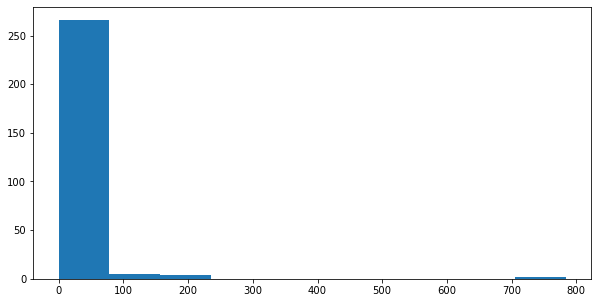

In [123]:
plt.hist(dists, bins=np.arange(0, len(dists)+1, 5))

In [16]:
print(([ y_and_preds[0], y_and_preds[1] ], [y_and_preds[2], y_and_preds[3]]))

IndexError: index 2 is out of bounds for axis 0 with size 2